In [ ]:
!pip install pandas numpy scikit-learn xgboost shap joblib matplotlib openpyxl


In [2]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [3]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    VotingRegressor,
    ExtraTreesRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.linear_model import RidgeCV
from xgboost import XGBRegressor

In [4]:
# Load Dataset
# =============================================================================

file_path = "BD_MedWaste_2000_2023.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())
print(df.columns.tolist())


Dataset loaded successfully.
Dataset shape: (192, 44)


,Year,Division,Number_of_Hospitals,Number_of_Beds,Crude_Birth_Rate,GDP_per_Capita_USD,Dengue_Cases,Beds_per_1000_Pop,Hospitals_per_100k_Pop,Avg_Beds_per_Hospital,...,Sharps_Waste_kg_day,Pharmaceutical_Waste_kg_day,Chemical_Waste_kg_day,Cytotoxic_Waste_kg_day,Pathological_Waste_kg_day,Radioactive_Waste_kg_day,Total_Hazardous_Waste_kg_day,Total_Medical_Waste_kg_day,Waste_per_Bed_kg_day,Hazardous_Waste_Pct
0,2000,Dhaka,749,30231,26.44,425.0,5088,573.643,142.13,40.4,...,1143.42,510.84,448.29,222.65,1416.56,32.832,16137.67,57838.24,1.9132,27.90
1,2000,Chattogram,357,13707,26.49,414.1,2039,403.147,105.00,38.4,...,551.80,228.95,189.64,130.92,467.44,7.119,7871.50,26488.36,1.9325,29.72
2,2000,Rajshahi,189,6627,25.99,404.0,382,354.385,101.07,35.1,...,301.18,193.42,173.98,43.66,385.09,8.487,4439.08,15249.01,2.3010,29.11
3,2000,Sylhet,146,4575,26.70,440.9,338,384.454,122.69,31.3,...,206.44,132.09,76.74,39.37,255.35,5.867,2859.95,11455.96,2.5040,24.96
4,2000,Khulna,203,6521,25.48,419.8,538,383.588,119.41,32.1,...,190.81,140.51,76.20,47.28,253.18,8.308,2728.05,9194.04,1.4099,29.67


['Year', 'Division', 'Number_of_Hospitals', 'Number_of_Beds', 'Crude_Birth_Rate', 'GDP_per_Capita_USD', 'Dengue_Cases', 'Beds_per_1000_Pop', 'Hospitals_per_100k_Pop', 'Avg_Beds_per_Hospital', 'Bed_Occupancy_Rate_Pct', 'Urban_Population_Pct', 'Area_km2', 'Population_Share_Pct', 'Tertiary_Hospitals', 'District_Hospitals', 'Upazila_Health_Complexes', 'Private_Clinics', 'Specialized_Hospitals', 'NGO_Facilities', 'Community_Health_Clinics', 'Diagnostic_Centers', 'Dengue_Rate_per_100k', 'Dengue_Category', 'Dengue_Waste_Adjustment', 'Birth_Rate_Category', 'GDP_Category', 'GDP_Growth_Pct', 'Waste_Mgmt_Coverage_Pct', 'Proper_Segregation_Pct', 'Facilities_with_Incinerator', 'Facilities_with_Autoclave', 'General_Waste_kg_day', 'Infectious_Waste_kg_day', 'Sharps_Waste_kg_day', 'Pharmaceutical_Waste_kg_day', 'Chemical_Waste_kg_day', 'Cytotoxic_Waste_kg_day', 'Pathological_Waste_kg_day', 'Radioactive_Waste_kg_day', 'Total_Hazardous_Waste_kg_day', 'Total_Medical_Waste_kg_day', 'Waste_per_Bed_kg_day',

In [ ]:
# Check Missing Values
# =============================================================================
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

display(missing_summary.sort_values(by="Missing_Percentage", ascending=False))


In [6]:
# prediction target
# =============================================================================

possible_targets = [
    "Total_Medical_Waste_kg_day",
    "Total_Hazardous_Waste_kg_day"
]

target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError("Target column not found. Please check your dataset column names.")

print("Selected target column:", target_col)

Selected target column: Total_Medical_Waste_kg_day


In [7]:
# create extra year feature
# =============================================================================

df_model = df.copy()

if "Year" in df_model.columns:
    df_model["Year_Index"] = df_model["Year"] - df_model["Year"].min()
    df_model["Year_Index_Squared"] = df_model["Year_Index"] ** 2

display(df_model.head())

,Year,Division,Number_of_Hospitals,Number_of_Beds,Crude_Birth_Rate,GDP_per_Capita_USD,Dengue_Cases,Beds_per_1000_Pop,Hospitals_per_100k_Pop,Avg_Beds_per_Hospital,...,Chemical_Waste_kg_day,Cytotoxic_Waste_kg_day,Pathological_Waste_kg_day,Radioactive_Waste_kg_day,Total_Hazardous_Waste_kg_day,Total_Medical_Waste_kg_day,Waste_per_Bed_kg_day,Hazardous_Waste_Pct,Year_Index,Year_Index_Squared
0,2000,Dhaka,749,30231,26.44,425.0,5088,573.643,142.13,40.4,...,448.29,222.65,1416.56,32.832,16137.67,57838.24,1.9132,27.90,0,0
1,2000,Chattogram,357,13707,26.49,414.1,2039,403.147,105.00,38.4,...,189.64,130.92,467.44,7.119,7871.50,26488.36,1.9325,29.72,0,0
2,2000,Rajshahi,189,6627,25.99,404.0,382,354.385,101.07,35.1,...,173.98,43.66,385.09,8.487,4439.08,15249.01,2.3010,29.11,0,0
3,2000,Sylhet,146,4575,26.70,440.9,338,384.454,122.69,31.3,...,76.74,39.37,255.35,5.867,2859.95,11455.96,2.5040,24.96,0,0
4,2000,Khulna,203,6521,25.48,419.8,538,383.588,119.41,32.1,...,76.20,47.28,253.18,8.308,2728.05,9194.04,1.4099,29.67,0,0


In [8]:
# prepare X and Y
# =============================================================================
waste_cols = [
    col for col in df_model.columns
    if "waste" in col.lower()
]

print("Waste-related columns removed from features:")
print(waste_cols)

X = df_model.drop(columns=waste_cols, errors="ignore")
y = df_model[target_col]

valid_index = y.dropna().index

X = X.loc[valid_index]
y = y.loc[valid_index]

print("Feature columns:")
print(X.columns.tolist())

print("X shape:", X.shape)
print("y shape:", y.shape)

Waste-related columns removed from features:
['Dengue_Waste_Adjustment', 'Waste_Mgmt_Coverage_Pct', 'General_Waste_kg_day', 'Infectious_Waste_kg_day', 'Sharps_Waste_kg_day', 'Pharmaceutical_Waste_kg_day', 'Chemical_Waste_kg_day', 'Cytotoxic_Waste_kg_day', 'Pathological_Waste_kg_day', 'Radioactive_Waste_kg_day', 'Total_Hazardous_Waste_kg_day', 'Total_Medical_Waste_kg_day', 'Waste_per_Bed_kg_day', 'Hazardous_Waste_Pct']
Feature columns:
['Year', 'Division', 'Number_of_Hospitals', 'Number_of_Beds', 'Crude_Birth_Rate', 'GDP_per_Capita_USD', 'Dengue_Cases', 'Beds_per_1000_Pop', 'Hospitals_per_100k_Pop', 'Avg_Beds_per_Hospital', 'Bed_Occupancy_Rate_Pct', 'Urban_Population_Pct', 'Area_km2', 'Population_Share_Pct', 'Tertiary_Hospitals', 'District_Hospitals', 'Upazila_Health_Complexes', 'Private_Clinics', 'Specialized_Hospitals', 'NGO_Facilities', 'Community_Health_Clinics', 'Diagnostic_Centers', 'Dengue_Rate_per_100k', 'Dengue_Category', 'Birth_Rate_Category', 'GDP_Category', 'GDP_Growth_Pct',

In [9]:
# =============================================================================
# Detect numeric and categorical columns
# =============================================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Year', 'Number_of_Hospitals', 'Number_of_Beds', 'Crude_Birth_Rate', 'GDP_per_Capita_USD', 'Dengue_Cases', 'Beds_per_1000_Pop', 'Hospitals_per_100k_Pop', 'Avg_Beds_per_Hospital', 'Bed_Occupancy_Rate_Pct', 'Urban_Population_Pct', 'Area_km2', 'Population_Share_Pct', 'Tertiary_Hospitals', 'District_Hospitals', 'Upazila_Health_Complexes', 'Private_Clinics', 'Specialized_Hospitals', 'NGO_Facilities', 'Community_Health_Clinics', 'Diagnostic_Centers', 'Dengue_Rate_per_100k', 'GDP_Growth_Pct', 'Proper_Segregation_Pct', 'Facilities_with_Incinerator', 'Facilities_with_Autoclave', 'Year_Index', 'Year_Index_Squared']

Categorical features:
['Division', 'Dengue_Category', 'Birth_Rate_Category', 'GDP_Category']


In [10]:
# Create preprocessing pipeline
# =============================================================================
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [11]:
# Train-test split
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 153
Testing rows: 39


In [12]:
# Evaluation Function
# =============================================================================

def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    non_zero_mask = y_true != 0

    if non_zero_mask.sum() == 0:
        return np.nan

    mape = np.mean(
        np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    ) * 100

    return mape


def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = calculate_mape(y_test, y_pred)

    result = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    }

    return result, y_pred


In [13]:
# Create models
# =============================================================================

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=700,
        max_depth=6,
        min_samples_split=2,
        random_state=42
    ))
])

gbm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    ))
])

adaboost = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", AdaBoostRegressor(
        n_estimators=800,
        learning_rate=0.03,
        random_state=42
    ))
])

extra_trees = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=900,
        max_depth=None,
        random_state=42
    ))
])

xgboost = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42
    ))
])

hist_gbm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=600,
        max_leaf_nodes=15,
        random_state=42
    ))
])

voting_regressor = VotingRegressor(
    estimators=[
        ("RF", rf),
        ("GBM", gbm),
        ("ExtraTrees", extra_trees),
        ("XGBoost", xgboost)
    ],
    weights=[2, 2, 3, 3]
)

stacking_regressor = StackingRegressor(
    estimators=[
        ("RF", rf),
        ("GBM", gbm),
        ("ExtraTrees", extra_trees),
        ("XGBoost", xgboost),
        ("HistGBM", hist_gbm)
    ],
    final_estimator=RidgeCV(),
    cv=5
)

models = {
    "Random Forest": rf,
    "Gradient Boosting": gbm,
    "AdaBoost": adaboost,
    "Extra Trees": extra_trees,
    "XGBoost": xgboost,
    "Hist Gradient Boosting": hist_gbm,
    "Voting Regressor": voting_regressor,
    "Stacking Regressor": stacking_regressor
}

print("All models created successfully.")


All models created successfully.


In [19]:
# =============================================================================
# Train models and get results
# =============================================================================
results = []
predictions = {}

for model_name, model in models.items():
    print("Training:", model_name)

    result, y_pred = evaluate_model(
        model,
        model_name,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append(result)
    predictions[model_name] = y_pred

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)

display(results_df)

Training: Random Forest
Training: Gradient Boosting
Training: AdaBoost
Training: Extra Trees
Training: XGBoost
Training: Hist Gradient Boosting
Training: Voting Regressor
Training: Stacking Regressor


,Model,MAE,RMSE,R2,MAPE (%)
1,Gradient Boosting,3391.125083,5879.390475,0.956506,9.481220
4,XGBoost,3838.538816,6959.095912,0.939064,10.711833
7,Stacking Regressor,4321.086074,7080.398294,0.936921,15.923796
6,Voting Regressor,4097.132647,7354.643811,0.931940,11.363773
0,Random Forest,5183.979969,8375.823666,0.911728,16.274156
3,Extra Trees,4835.217906,8881.488395,0.900748,14.066167
2,AdaBoost,7470.652000,10968.545134,0.848621,29.923492
5,Hist Gradient Boosting,6878.786713,11268.209740,0.840237,21.469518


In [20]:
# Select best model 
# =============================================================================

best_result = results_df.iloc[0]

best_model_name = best_result["Model"]
best_model = models[best_model_name]
best_prediction = predictions[best_model_name]

print("Best Model:", best_model_name)
print("R2:", best_result["R2"])
print("MAE:", best_result["MAE"])
print("RMSE:", best_result["RMSE"])
print("MAPE (%):", best_result["MAPE (%)"])

Best Model: Gradient Boosting
R2: 0.9565058046854774
MAE: 3391.1250825782363
RMSE: 5879.390475142568
MAPE (%): 9.481219696290474


In [ ]:
# Actual vs predicted values
# =============================================================================

prediction_df = pd.DataFrame({
    "Actual_Value": y_test.values,
    "Predicted_Value": best_prediction,
    "Error": y_test.values - best_prediction,
    "Absolute_Error": np.abs(y_test.values - best_prediction)
})

display(prediction_df.head(20))

prediction_df.to_csv("bangladesh_actual_vs_predicted.csv", index=False)

print("Saved: bangladesh_actual_vs_predicted.csv")

In [ ]:

# Actual vs predicted graph
# =============================================================================

plt.figure(figsize=(7, 6))

plt.scatter(y_test, best_prediction)

min_value = min(y_test.min(), best_prediction.min())
max_value = max(y_test.max(), best_prediction.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Medical Waste")
plt.ylabel("Predicted Medical Waste")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

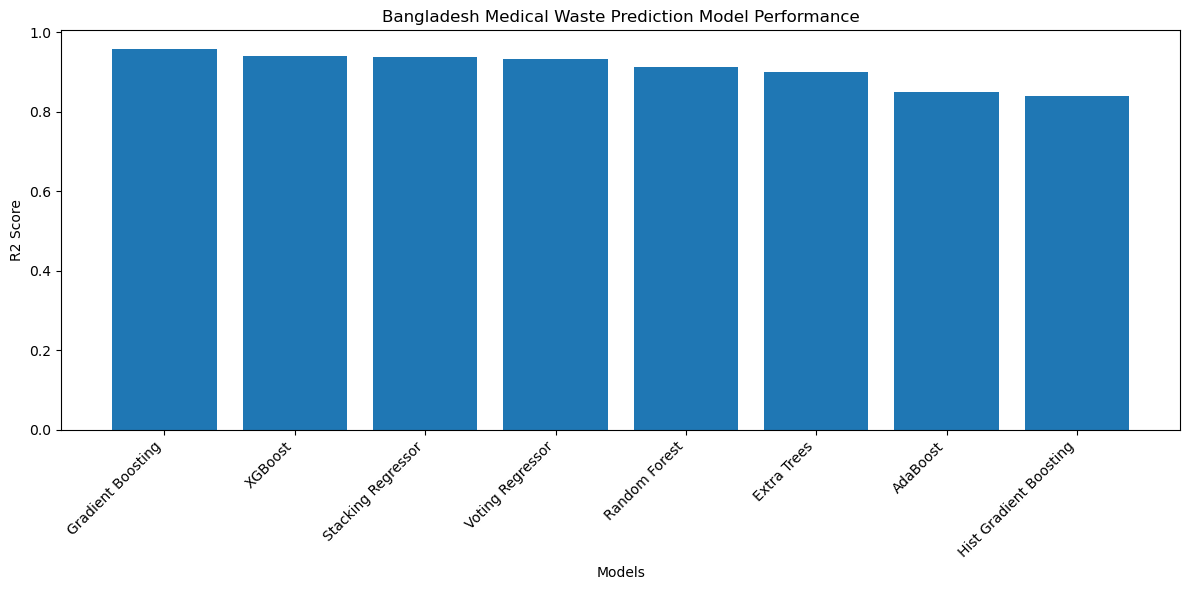

In [28]:
#Model performance graph
plt.figure(figsize=(12, 6))

plt.bar(results_df["Model"], results_df["R2"])

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Bangladesh Medical Waste Prediction Model Performance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
#Save results and best model
best_model.fit(X, y)

joblib.dump(best_model, "best_bangladesh_medical_waste_model.pkl")

results_df.to_csv("bangladesh_model_results.csv", index=False)
cv_results_df.to_csv("bangladesh_cross_validation_results.csv", index=False)

print("Saved files:")
print("best_bangladesh_medical_waste_model.pkl")
print("bangladesh_model_results.csv")
print("bangladesh_cross_validation_results.csv")
print("bangladesh_actual_vs_predicted.csv")

In [27]:
#Print final report result
print("Final Bangladesh Medical Waste Prediction Result")
print("------------------------------------------------")
print("Best Model:", best_model_name)
print("R2 Score:", round(best_result["R2"], 4))
print("MAE:", round(best_result["MAE"], 4))
print("RMSE:", round(best_result["RMSE"], 4))
print("MAPE (%):", round(best_result["MAPE (%)"], 4))

Final Bangladesh Medical Waste Prediction Result
------------------------------------------------
Best Model: Gradient Boosting
R2 Score: 0.9565
MAE: 3391.1251
RMSE: 5879.3905
MAPE (%): 9.4812
